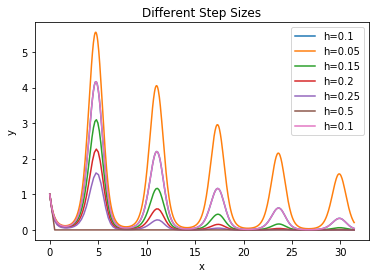

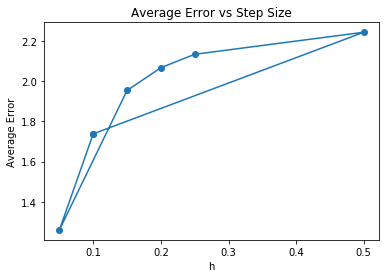

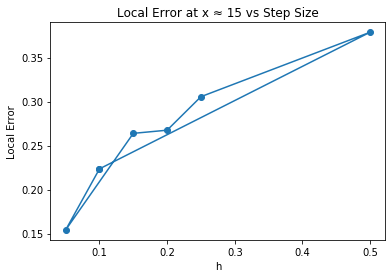

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h_values = [0.1,0.05,0.15,0.2,0.25,0.5,1] # step size

x_start, x_end = 0, 10*np.pi

def exact(x):
    return np.exp(-2 * np.sin(x))

# Function representing dy/dx = -2y*cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

average_errs = []
local_errs = []

plt.figure()

for h in h_values:
    
    num_steps = int((x_end - x_start) / h)
    
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1 # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    y_exact = exact(x_values)
    
    average_err = np.mean(np.abs(y_values - y_exact))
    average_errs.append(average_err)
    
    # Asked ChatGPT for help on how to compare to x = 15
    idx = np.argmin(np.abs(x_values - 15))
    
    local_err = abs(y_values[idx] - y_exact[idx])
    local_errs.append(local_err)

    plt.plot(x_values, y_values, label=f"h={h}")
    
# Plot the results
plt.xlabel('x')
plt.ylabel('y')
plt.title("Different Step Sizes")
plt.legend()
plt.show()

plt.figure()
plt.plot(h_values, average_errs, marker='o')
plt.title("Average Error vs Step Size")
plt.xlabel("h")
plt.ylabel("Average Error")
plt.show()

plt.figure()
plt.plot(h_values, local_errs, marker='o')
plt.title("Local Error at x ≈ 15 vs Step Size")
plt.xlabel("h")
plt.ylabel("Local Error")
plt.show()

# As h increases, the average and local error increase, which means the lower h is the more accurate the solution is.
# Ran my code through ChatGPT to ensure no errors and met what the HW was asking for